# Task 4 — Proxy Target Variable Engineering

The raw dataset has no default label. Here we build one by clustering
customers on RFM (Recency, Frequency, Monetary) behavior and labeling the
most disengaged cluster as high-risk.

**This label is a modeling assumption, not verified ground truth** — we will see the
final report for a discussion of the business risk this introduces.

In [2]:
import sys; sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import (
    load_raw_data,
    compute_customer_features,
    compute_rfm,
    cluster_rfm,
    identify_high_risk_cluster,
    build_risk_label,
    OutlierCapper,
)

sns.set_theme(style="whitegrid", palette="tab10")

In [3]:
# again here we are loading the customer features with the rfm that we saved
# from feature_engineering_trimmed.ipynb, we will remove the rfm features in the pipeline 
customer_features = pd.read_csv("../data/processed/customer_features_rfm.csv")
customer_features.shape

(3742, 32)

## Build the proxy label
RFM → scale → KMeans (k=3, random_state=42) → identify most-disengaged cluster.

In [4]:
labeled = build_risk_label(customer_features)
print(labeled["is_high_risk"].value_counts())
print(f"High-risk rate: {labeled['is_high_risk'].mean():.2%}")
labeled.head()

2026-09-07 17:30:34,967 [INFO] RFM table assembled for 3742 customers.
2026-09-07 17:30:37,497 [INFO] KMeans fit complete. Cluster sizes:
cluster
1    2315
0    1426
2       1
Name: count, dtype: int64
2026-09-07 17:30:37,500 [INFO] Cluster profiles (mean values):
           Recency    Frequency      Monetary
cluster                                      
0        61.877279     7.720196  8.172068e+04
1        12.726566    34.800000  2.725741e+05
2        29.000000  4091.000000 -1.049000e+08
2026-09-07 17:30:37,508 [INFO] Disengagement rank-sum per cluster (lower = more disengaged):
cluster
0    4.0
1    8.0
2    6.0
dtype: float64
2026-09-07 17:30:37,510 [INFO] Identified cluster 0 as high-risk (most disengaged).
2026-09-07 17:30:37,517 [INFO] Final is_high_risk distribution:
is_high_risk
0    2316
1    1426
Name: count, dtype: int64
2026-09-07 17:30:37,519 [INFO] High-risk percentage: 38.108%


profile ranking
cluster
0    1.0
1    2.0
2    3.0
Name: Frequency, dtype: float64
disengagement rank sum
cluster
0    4.0
1    8.0
2    6.0
dtype: float64
is_high_risk
0    2316
1    1426
Name: count, dtype: int64
High-risk rate: 38.11%


,CustomerId,total_amount,avg_amount,std_amount,transaction_count,total_value,fraud_count,first_txn,last_txn,txn_hour_mean,...,preferred_hour,weekend_ratio,unique_products,unique_categories,unique_providers,ChannelId_1,ChannelId_2,ChannelId_3,ChannelId_5,is_high_risk
0,CustomerId_1,-10000.0,-10000.000000,0.000000,1,10000,0,2018-11-21 16:49:14+00:00,2018-11-21 16:49:14+00:00,16.000000,...,16,0.000000,1,1,1,0,1,0,0,1
1,CustomerId_10,-10000.0,-10000.000000,0.000000,1,10000,0,2018-11-21 16:49:09+00:00,2018-11-21 16:49:09+00:00,16.000000,...,16,0.000000,1,1,1,0,1,0,0,1
2,CustomerId_1001,20000.0,4000.000000,6558.963333,5,30400,0,2018-11-16 07:53:19+00:00,2018-11-16 08:20:39+00:00,7.800000,...,8,0.000000,3,2,3,0,2,3,0,1
3,CustomerId_1002,4225.0,384.090909,560.498966,11,4775,0,2018-11-15 18:50:09+00:00,2019-01-18 10:05:00+00:00,13.454545,...,14,0.181818,3,2,2,0,6,5,0,0
4,CustomerId_1003,20000.0,3333.333333,6030.478146,6,32000,0,2019-02-01 14:58:07+00:00,2019-02-01 15:04:51+00:00,14.333333,...,14,0.000000,4,2,3,0,2,4,0,0


## Why this cluster? Validating the high-risk assignment

Rebuild the RFM/cluster view directly so we can show cluster centers side by
side — this is the plot that justifies the label to a non-technical reader.

2026-08-01 21:25:24,811 [INFO] RFM table assembled for 3742 customers.
2026-08-01 21:25:24,836 [INFO] KMeans fit complete. Cluster sizes:
cluster
1    2315
0    1426
2       1
Name: count, dtype: int64
2026-08-01 21:25:24,839 [INFO] Cluster profiles (mean values):
           Recency    Frequency      Monetary
cluster                                      
0        61.877279     7.720196  8.172068e+04
1        12.726566    34.800000  2.725741e+05
2        29.000000  4091.000000 -1.049000e+08
2026-08-01 21:25:24,844 [INFO] Disengagement rank-sum per cluster (lower = more disengaged):
cluster
0    4.0
1    8.0
2    6.0
dtype: float64
2026-08-01 21:25:24,846 [INFO] Identified cluster 0 as high-risk (most disengaged).


           Recency    Frequency      Monetary
cluster                                      
0        61.877279     7.720196  8.172068e+04
1        12.726566    34.800000  2.725741e+05
2        29.000000  4091.000000 -1.049000e+08


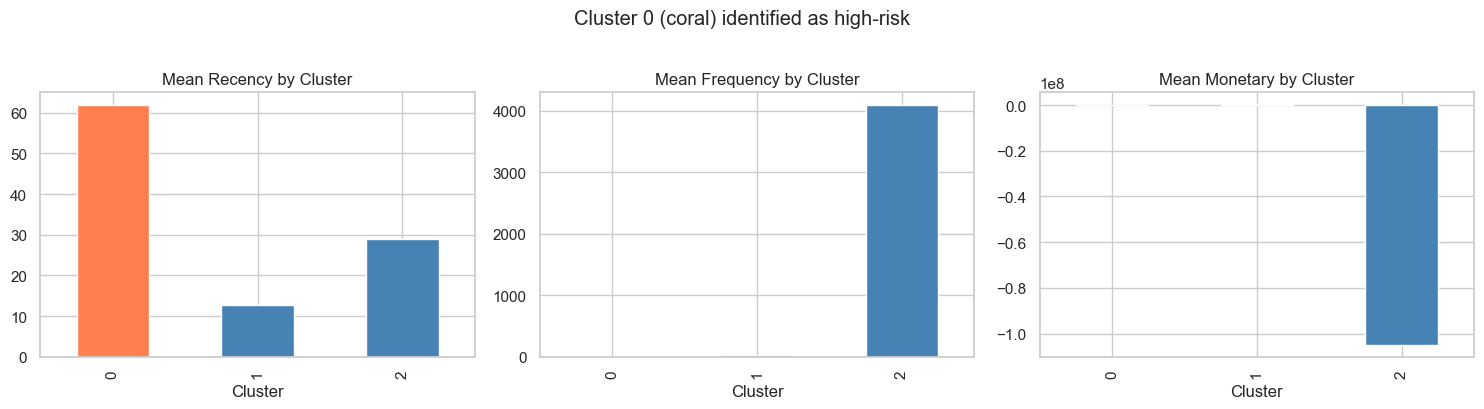

In [4]:
rfm = compute_rfm(customer_features)
rfm, kmeans, scaler = cluster_rfm(rfm)
high_risk_cluster = identify_high_risk_cluster(rfm)

profile = rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(profile)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    colors = ["coral" if c == high_risk_cluster else "steelblue" for c in profile.index]
    profile[col].plot(kind="bar", ax=ax, color=colors)
    ax.set_title(f"Mean {col} by Cluster")
    ax.set_xlabel("Cluster")
plt.suptitle(f"Cluster {high_risk_cluster} (coral) identified as high-risk", y=1.02)
plt.tight_layout(); plt.show()

## Customer-Level Distributions by Risk Label
Compare high-risk vs low-risk customers across RFM features.

2026-08-01 21:25:32,120 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-01 21:25:32,129 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-01 21:25:32,238 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-01 21:25:32,248 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-01 21:25:32,353 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

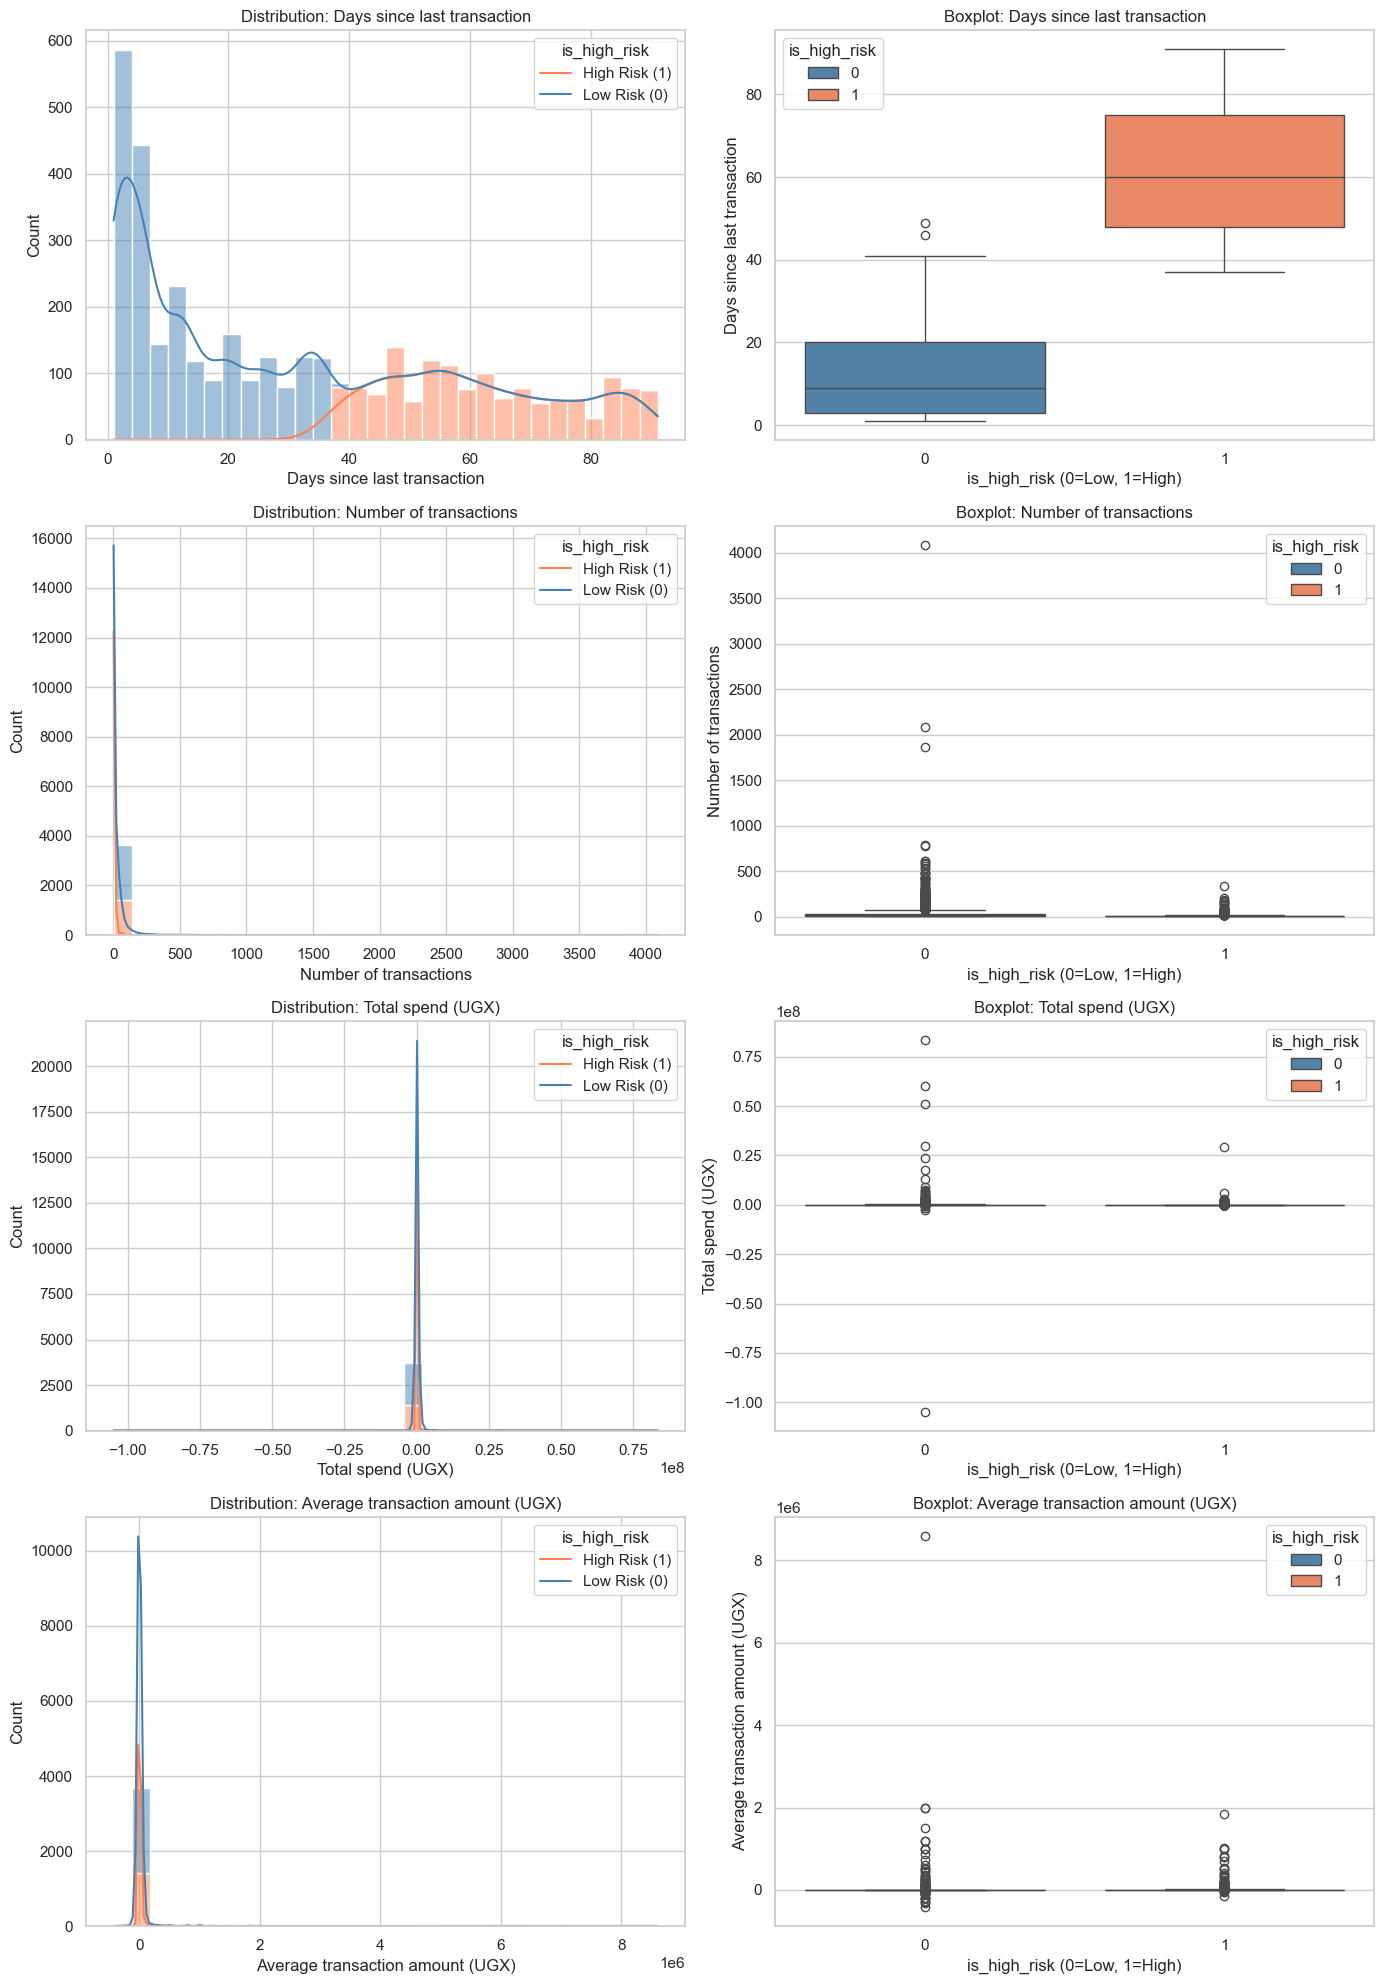

In [5]:
rfm_plot_cols = [
    ("recency_days",      "Days since last transaction"),
    ("transaction_count", "Number of transactions"),
    ("total_amount",      "Total spend (UGX)"),
    ("avg_amount",        "Average transaction amount (UGX)"),
]

fig, axes = plt.subplots(len(rfm_plot_cols), 2, figsize=(14, 5 * len(rfm_plot_cols)))

for i, (col, label) in enumerate(rfm_plot_cols):
    sns.histplot(
        data=labeled, x=col, hue="is_high_risk",
        kde=True, multiple="stack",
        hue_order=[0, 1],
        palette={0: "steelblue", 1: "coral"},
        ax=axes[i, 0], bins=30
    )
    axes[i, 0].set_title(f"Distribution: {label}")
    axes[i, 0].set_xlabel(label)
    axes[i, 0].legend(title="is_high_risk", labels=["High Risk (1)", "Low Risk (0)"])

    sns.boxplot(
        data=labeled, x="is_high_risk", y=col,
        hue="is_high_risk",
        palette={0: "steelblue", 1: "coral"},
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot: {label}")
    axes[i, 1].set_xlabel("is_high_risk (0=Low, 1=High)")
    axes[i, 1].set_ylabel(label)

plt.tight_layout()
plt.show()

## Correlation Analysis — RFM & Related Features

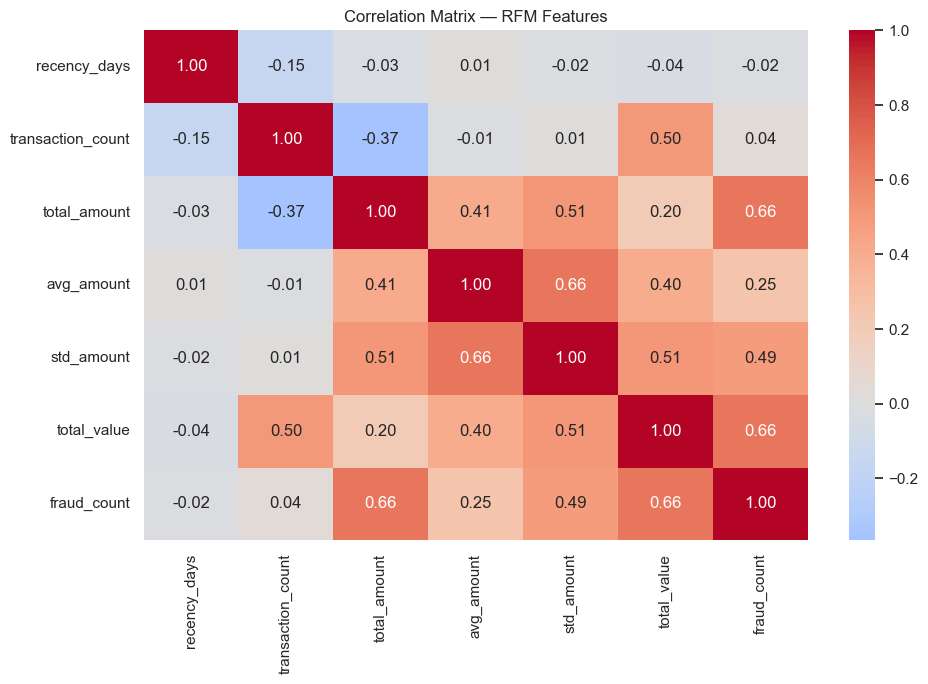

In [6]:
rfm_num = labeled[["recency_days", "transaction_count", "total_amount",
                    "avg_amount", "std_amount", "total_value", "fraud_count"]]

plt.figure(figsize=(10, 7))
sns.heatmap(rfm_num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — RFM Features")
plt.tight_layout(); plt.show()

## Outlier Detection (Pre-Capping)

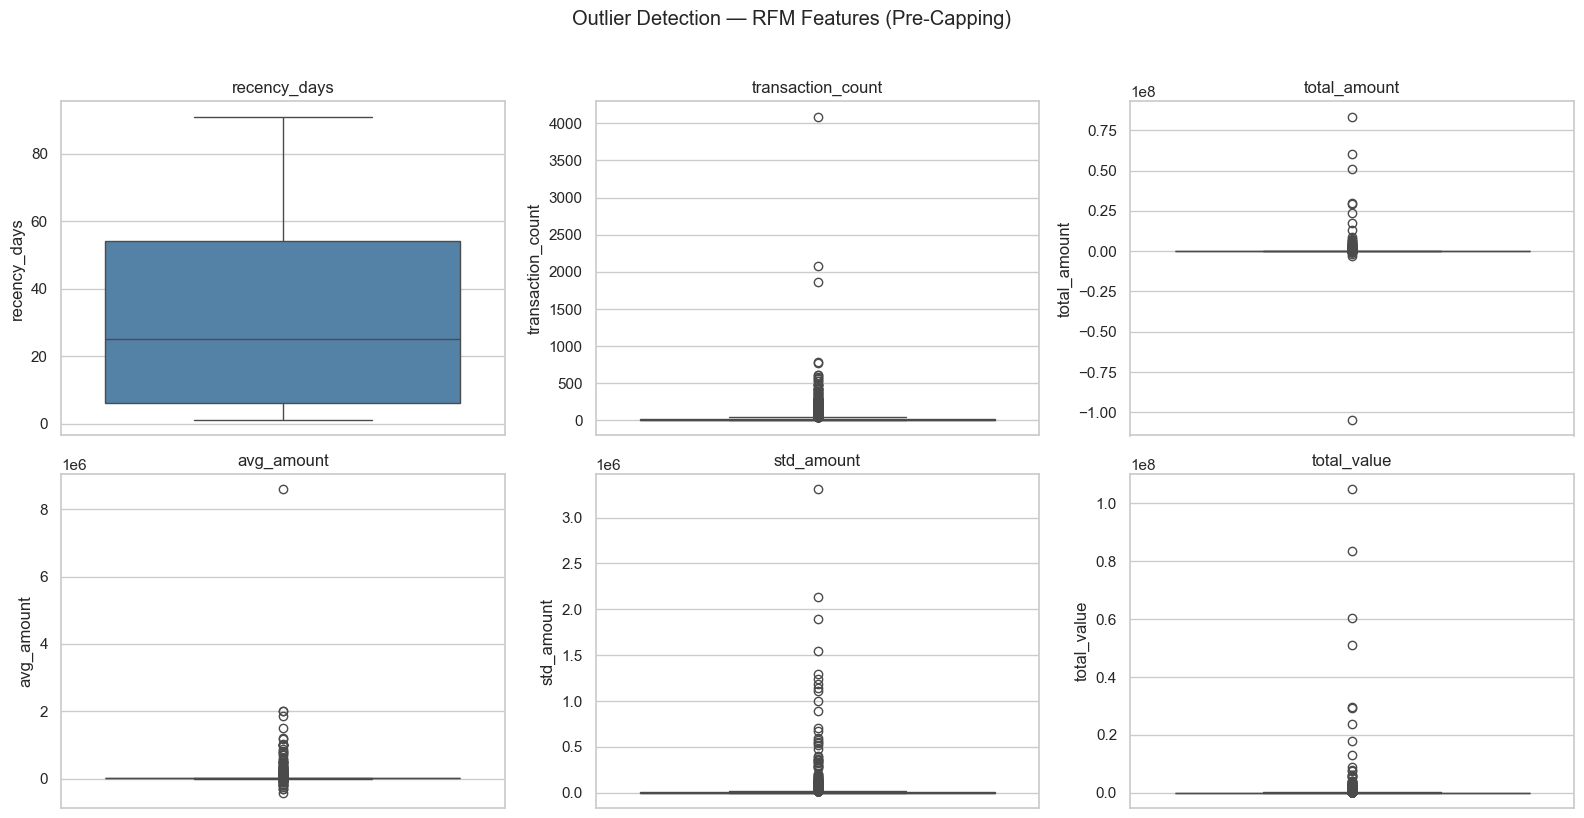

In [7]:
cols_to_check = ["recency_days", "transaction_count", "total_amount",
                  "avg_amount", "std_amount", "total_value"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cols_to_check):
    sns.boxplot(y=labeled[col], ax=ax, color="steelblue")
    ax.set_title(col)

plt.suptitle("Outlier Detection — RFM Features (Pre-Capping)", y=1.02)
plt.tight_layout(); plt.show()

## Outlier Capping (Winsorization)
IQR-based capping: values below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR` are clipped.

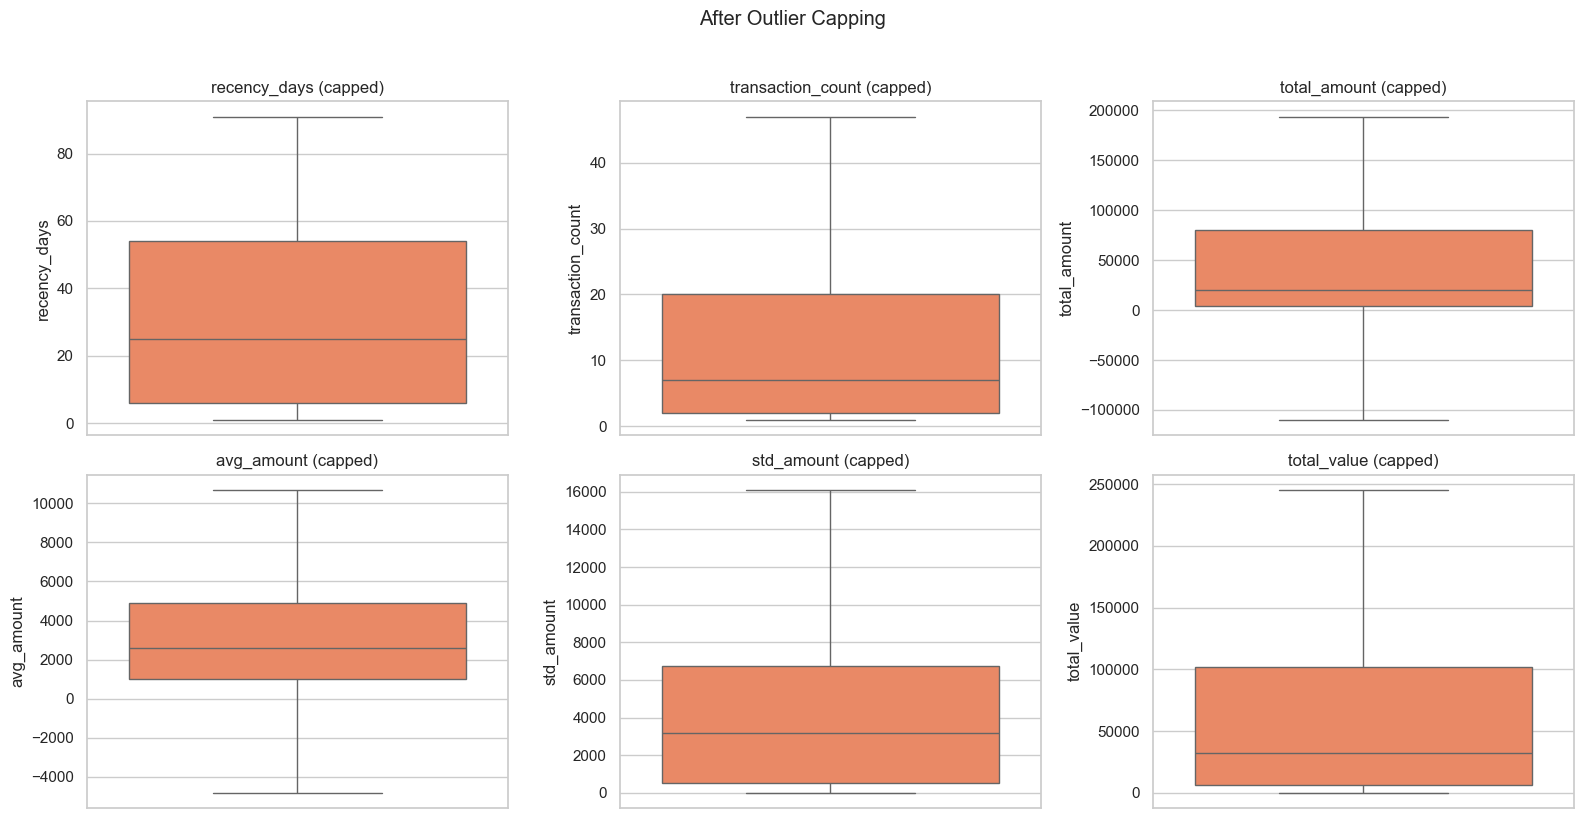

In [8]:
capper = OutlierCapper(cols=cols_to_check)
labeled_capped = capper.fit_transform(labeled)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cols_to_check):
    sns.boxplot(y=labeled_capped[col], ax=ax, color="coral")
    ax.set_title(f"{col} (capped)")

plt.suptitle("After Outlier Capping", y=1.02)
plt.tight_layout(); plt.show()